# Partie 1 - Exploration des donnees

Detection de tweets suspects. On charge le fichier de tweets, on regarde un peu a quoi ressemblent les donnees, et on prepare le texte pour la suite.

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from text_cleaning import clean_text

sns.set_theme(style="whitegrid")


## Chargement des donnees

In [2]:
df = pd.read_csv("../data/raw/tweets_suspect.csv")
print(df.shape)
df.head()


(60000, 2)


,message,label
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",1
1,is upset that he can't update his Facebook by ...,1
2,@Kenichan I dived many times for the ball. Man...,1
3,my whole body feels itchy and like its on fire,0
4,"@nationwideclass no, it's not behaving at all....",1


## Les variables

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   message  60000 non-null  str  
 1   label    60000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 5.1 MB


## Valeurs manquantes

In [4]:
df.isna().sum()


message    0
label      0
dtype: int64

## Distribution des classes

label = 1 -> tweet suspect, label = 0 -> tweet normal. On voit tout de suite qu'il y a beaucoup plus de tweets normaux que de tweets suspects, ce qui va poser un probleme de desequilibre qu'on devra traiter plus tard (partie 4).

label
1    53855
0     6145
Name: count, dtype: int64
label
1    89.76
0    10.24
Name: count, dtype: float64


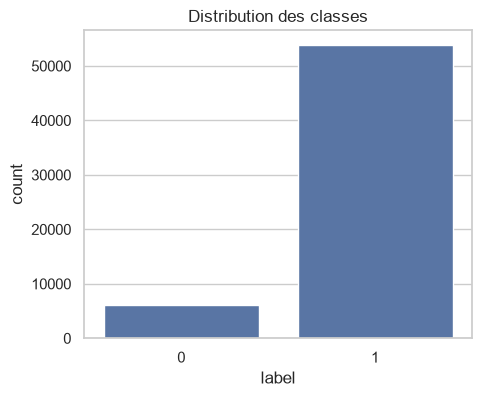

In [5]:
counts = df["label"].value_counts()
print(counts)
print((counts / counts.sum() * 100).round(2))

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(x="label", data=df, ax=ax)
ax.set_title("Distribution des classes")
plt.savefig("../reports/figures/class_distribution.png")
plt.show()


## Longueur des tweets

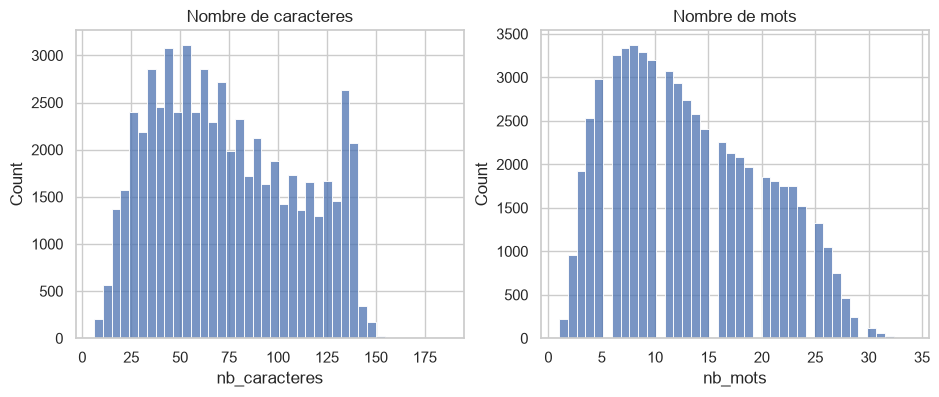

In [6]:
df["nb_caracteres"] = df["message"].str.len()
df["nb_mots"] = df["message"].str.split().apply(len)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["nb_caracteres"], bins=40, ax=axes[0])
axes[0].set_title("Nombre de caracteres")
sns.histplot(df["nb_mots"], bins=40, ax=axes[1])
axes[1].set_title("Nombre de mots")
plt.savefig("../reports/figures/tweet_length_distribution.png")
plt.show()


## Nettoyage du texte

Un tweet contient beaucoup d'elements qui n'apportent rien pour classer le texte, et qui peuvent meme perturber le modele. Voici les choix faits et pourquoi :

- **Minuscules** : pour eviter que 'Free' et 'free' soient comptes comme deux mots differents.
- **Suppression des URLs** : un lien ne dit rien sur le contenu du message, et change a chaque tweet.
- **Suppression des mentions (@) et du symbole #** : les noms d'utilisateurs sont trop specifiques   a chaque tweet, ils n'aident pas a generaliser. On garde quand meme le mot du hashtag, seul le symbole part.
- **Suppression des caracteres speciaux et de la ponctuation** : on ne garde que les lettres,   pour reduire le bruit dans le vocabulaire.
- **Suppression des stop words** (mots comme *the*, *is*, *and*...) : ce sont des mots tres frequents   mais qui ne portent pas de sens particulier, ils gonfleraient le vocabulaire pour rien.
- **Lemmatisation** : on ramene chaque mot a sa forme de base (par exemple *running* -> *run*),   pour que des mots proches soient traites comme un seul et meme mot. On aurait aussi pu faire   du stemming (juste couper la fin des mots), mais la lemmatisation donne des mots plus lisibles,   ce qui aide aussi a l'interpretation.

In [7]:
for texte in df["message"].head(5):
    print("avant :", texte)
    print("apres :", clean_text(texte))
    print("-" * 60)


avant : @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D


apres : awww bummer shoulda got david carr third day
------------------------------------------------------------
avant : is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!
apres : upset update facebook texting might cry result school today also blah
------------------------------------------------------------
avant : @Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds
apres : dived many time ball managed save rest go bound
------------------------------------------------------------
avant : my whole body feels itchy and like its on fire 
apres : whole body feel itchy like fire
------------------------------------------------------------
avant : @nationwideclass no, it's not behaving at all. i'm mad. why am i here? because I can't see you all over there. 
apres : behaving mad see
------------------------------------------------------------


## Mots les plus frequents par classe

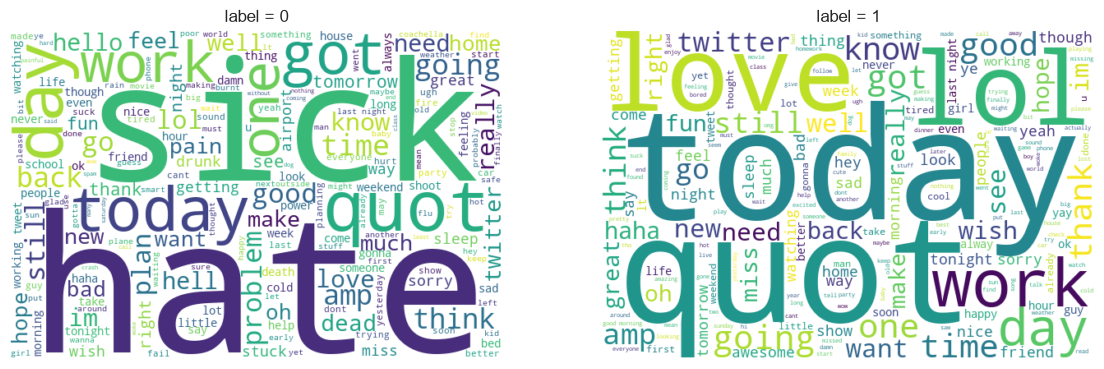

In [8]:
df["clean_text"] = df["message"].apply(clean_text)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for label, ax in zip([0, 1], axes):
    texte = " ".join(df.loc[df["label"] == label, "clean_text"])
    wc = WordCloud(width=600, height=400, background_color="white").generate(texte)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"label = {label}")
plt.savefig("../reports/figures/wordclouds.png")
plt.show()


## Ce qu'on retient

Il n'y a pas de valeurs manquantes qui posent probleme apres nettoyage. Par contre, les classes sont tres desequilibrees (environ 90% / 10%), donc il faudra en tenir compte pour l'entrainement des modeles. Les tweets restent assez courts, ce qui rend une representation TF-IDF adaptee pour commencer.